<a href="https://colab.research.google.com/github/nikhilvkth/ECG-Signal-analysis/blob/main/edf20_EEG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

pip install mne matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 34.0 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


/tmp/ipykernel_3149/981463613.py:11: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_3149/981463613.py:11: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
/tmp/ipykernel_3149/981463613.py:11: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Available channels in this file: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Plotting channel: EEG Fpz-Cz


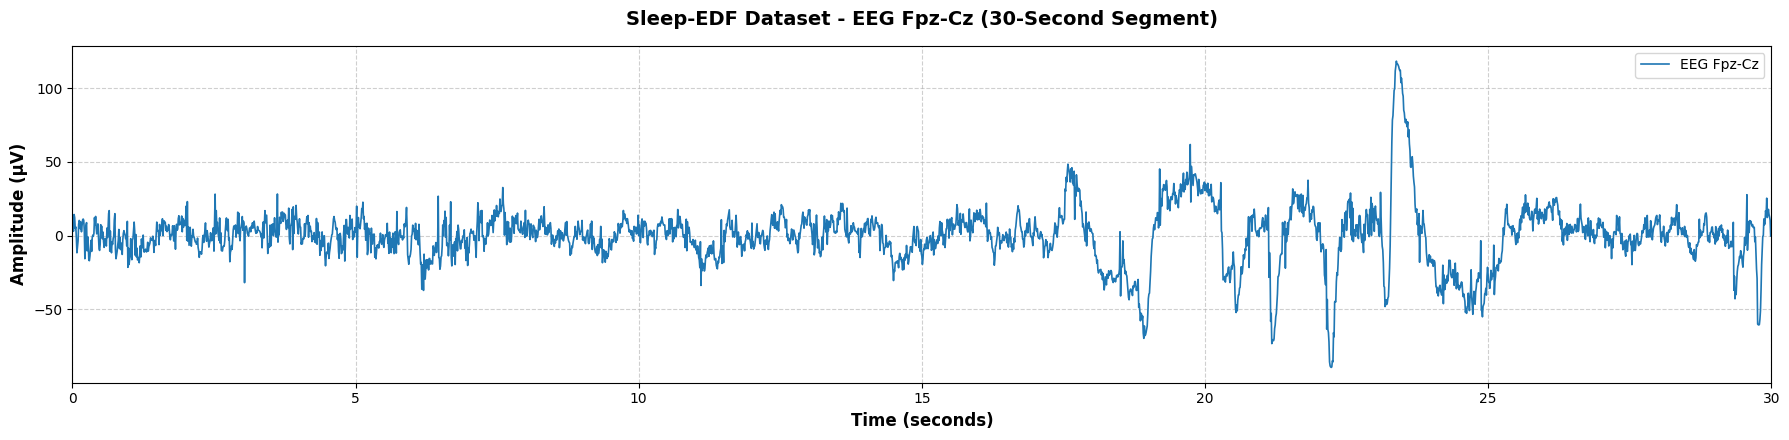

In [ ]:
import mne
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the path to your local EDF file
# Replace this with the actual path to one of your downloaded files
file_path = '/content/SC4001E0-PSG.edf'

try:
    # 2. Load the EDF file (exclude stimulus/annotation track for clean signal reading)
    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

    # Print available channels so you can verify what is inside your file
    print("Available channels in this file:", raw.ch_names)

    # 3. Select the channel you wish to plot.
    # Change 'EEG Fpz-Cz' to your leg channel if your specific file contains it.
    target_channel = raw.ch_names[0]
    print(f"Plotting channel: {target_channel}")

    # 4. Extract data parameters
    sfreq = raw.info['sfreq']  # Sampling frequency (usually 100 Hz for Sleep-EDF) (Wang et al., 2023)

    # Let's extract a 30-second segment (standard epoch length for sleep data) (Wang et al., 2023)
    start_time = 600   # Start at minute 10 of the recording
    duration = 30      # Duration in seconds

    start_sample = int(start_time * sfreq)
    end_sample = int((start_time + duration) * sfreq)

    # Get the data matrix and corresponding time vector
    data, times = raw[target_channel, start_sample:end_sample]

    # Flatten data array from 2D (channels x samples) to 1D (samples)
    signal_amplitude = data[0] * 1e6  # Convert Volts to Microvolts (uV) for standard medical display
    relative_times = times - start_time # Normalize time axis to start at 0 seconds

    # 5. Plotting
    plt.figure(figsize=(18, 4.5))
    plt.plot(relative_times, signal_amplitude, color='#1f77b4', linewidth=1.2, label=target_channel)

    # Labeling Axes and styling
    plt.title(f"Sleep-EDF Dataset - {target_channel} (30-Second Segment)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Time (seconds)", fontsize=12, fontweight='semibold')
    plt.ylabel("Amplitude (μV)", fontsize=12, fontweight='semibold')

    plt.xlim(0, duration)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc="upper right")
    plt.tight_layout()

    # Display the plot
    plt.show()

except FileNotFoundError:
    print(f"Error: The file at '{file_path}' was not found. Please verify your local folder path.")
except Exception as e:
    print(f"An error occurred: {e}")